In [2]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA

In [3]:
#Load data from USGS API (past 6 months, magnitude >= 4)
url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2025-05-01&minmagnitude=4"
data = requests.get(url).json()

In [5]:
#Convert to DataFrame
records = []
for feature in data["features"]:
    props = feature["properties"]
    geom = feature["geometry"]
    if geom and geom["type"] == "Point":
        lon, lat, depth = geom["coordinates"]
        records.append({
            "place": props.get("place"),
            "mag": props.get("mag"),
            "depth": depth,
            "latitude": lat,
            "longitude": lon,
            "time": pd.to_datetime(props.get("time"), unit="ms")
        })

df = pd.DataFrame(records).dropna(subset=["mag", "depth", "latitude", "longitude"])
print("Loaded", len(df), "earthquake records")


Loaded 10475 earthquake records


In [6]:
#Feature selection and scaling
features = df[["latitude", "longitude", "depth", "mag"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


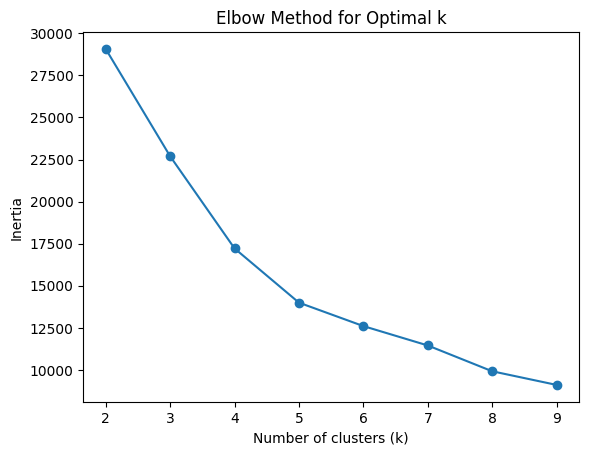

In [7]:
#Elbow Method
inertia = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()


In [29]:
#Cluster using k=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)


In [28]:
#Density Map
fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="cluster",
    hover_name="place",
    size="mag",
    title="Global Earthquake Clusters (k=5)"
)
fig.update_geos(showcoastlines=True, projection_type="natural earth")
fig.show()

In [23]:
#Dimension Reduction
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)
df["PC1"] = reduced[:, 0]
df["PC2"] = reduced[:, 1]

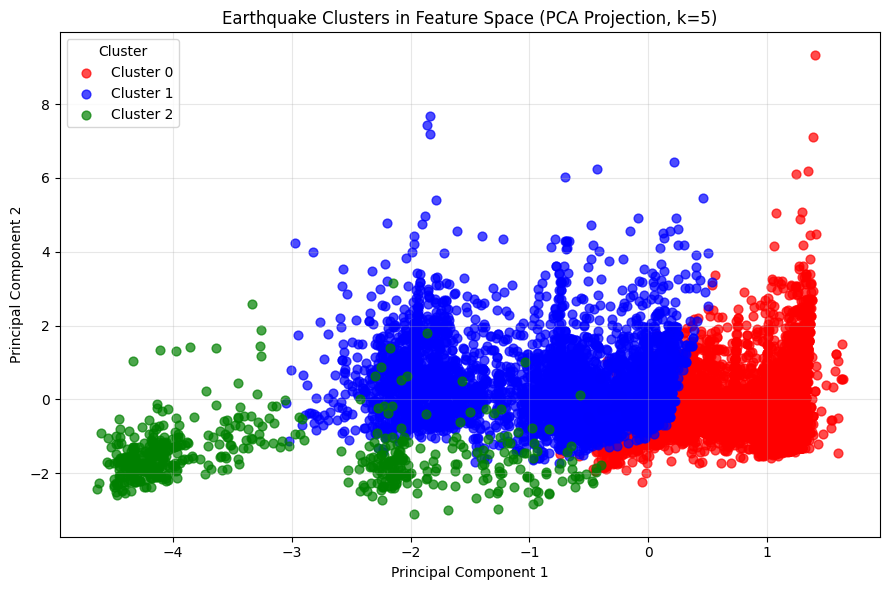

In [24]:
#Visualization
colors = ["red", "blue", "green", "orange", "purple"]
plt.figure(figsize=(9, 6))
for i in range(k):
    cluster_points = df[df["cluster"] == i]
    plt.scatter(
        cluster_points["PC1"],
        cluster_points["PC2"],
        color=colors[i],
        label=f"Cluster {i}",
        alpha=0.7,
        s=40
    )

plt.title("Earthquake Clusters in Feature Space (PCA Projection, k=5)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
